In [ ]:
import os
import numpy as np
import librosa
from tqdm import tqdm
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Paths
DATASET_PATH = "/content/drive/MyDrive/Audio_project_CRNN_GRU/Dataset_audio"
MODEL_DIR = "/content/drive/MyDrive/Audio_project_CRNN_GRU/Model"

BEST_MODEL_DIR = os.path.join(MODEL_DIR, "best_model")
CHECKPOINT_DIR = os.path.join(MODEL_DIR, "checkpoints")

os.makedirs(BEST_MODEL_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

In [ ]:
def extract_features(file_path, max_pad_len=128):

    try:

        audio, sr = librosa.load(file_path, sr=22050)

        # Skip tiny/broken audio
        if len(audio) < 2048:
            return None

        mel = librosa.feature.melspectrogram(
            y=audio,
            sr=sr,
            n_mels=128
        )

        mel_db = librosa.power_to_db(
            mel,
            ref=np.max
        )

        # Pad / truncate
        if mel_db.shape[1] < max_pad_len:

            pad_width = max_pad_len - mel_db.shape[1]

            mel_db = np.pad(
                mel_db,
                ((0,0),(0,pad_width)),
                mode='constant'
            )

        else:
            mel_db = mel_db[:, :max_pad_len]

        # Better normalization
        mel_db = librosa.util.normalize(mel_db)

        return mel_db.astype(np.float32)

    except Exception as e:

        print(f"ERROR loading {file_path}")
        print(e)

        return None

In [ ]:
def load_dataset(base_path):

    X = []
    y = []

    suspicious_path = os.path.join(base_path, "suspicious")
    non_suspicious_path = os.path.join(base_path, "non_suspicious")

    # =========================
    # SUSPICIOUS
    # =========================
    for category in os.listdir(suspicious_path):

        category_path = os.path.join(suspicious_path, category)

        if not os.path.isdir(category_path):
            continue

        wav_files = [
            f for f in os.listdir(category_path)
            if f.lower().endswith(".wav")
        ]

        print(f"\nLoading suspicious/{category}: {len(wav_files)} files")

        for file in tqdm(wav_files):

            file_path = os.path.join(category_path, file)

            features = extract_features(file_path)

            if features is not None:

                X.append(features)
                y.append(1)

    # =========================
    # NON SUSPICIOUS
    # =========================
    for category in os.listdir(non_suspicious_path):

        category_path = os.path.join(non_suspicious_path, category)

        if not os.path.isdir(category_path):
            continue

        wav_files = [
            f for f in os.listdir(category_path)
            if f.lower().endswith(".wav")
        ]

        print(f"\nLoading non_suspicious/{category}: {len(wav_files)} files")

        for file in tqdm(wav_files):

            file_path = os.path.join(category_path, file)

            features = extract_features(file_path)

            if features is not None:

                X.append(features)
                y.append(0)

    X = np.array(X, dtype=np.float32)
    y = np.array(y)

    return X, y

In [ ]:
print("Loading dataset...")
X, y = load_dataset(DATASET_PATH)
print("Shape:", X.shape, y.shape)
# Add channel dimension
X = X[..., np.newaxis]
# Train-test split
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("\nTrain shape:", X_train.shape)
print("Validation shape:", X_val.shape)

Loading dataset...

Loading suspicious/scream: 200 files


100%|██████████| 200/200 [00:30<00:00,  6.66it/s]



Loading suspicious/shout: 6 files


100%|██████████| 6/6 [00:07<00:00,  1.23s/it]



Loading suspicious/crying: 32 files


...


Loading non_suspicious/cremad_neutral: 1087 files


100%|██████████| 1087/1087 [00:40<00:00, 26.95it/s]



Loading non_suspicious/cremad_happy: 1271 files


100%|██████████| 1271/1271 [00:51<00:00, 24.54it/s]


Shape: (6873, 128, 128) (6873,)

Train shape: (5498, 128, 128, 1)
Validation shape: (1375, 128, 128, 1)


In [ ]:
def build_model(input_shape=(128,128,1)):
    inputs = tf.keras.Input(shape=input_shape)
    # =====================================
    # CNN BLOCK 1
    # =====================================
    x = layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        padding='same'
    )(inputs)

    x = layers.BatchNormalization()(x)

    x = layers.MaxPooling2D((2,2))(x)
    # =====================================
    # CNN BLOCK 2
    # =====================================
    x = layers.Conv2D(
        64,
        (3,3),
        activation='relu',
        padding='same'
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)
    # =====================================
    # CONVERT TO SEQUENCE
    # =====================================
    x = layers.Permute((2,1,3))(x)
    x = layers.Reshape(
        (x.shape[1], -1)
    )(x)
    # =====================================
    # BIDIRECTIONAL GRU
    # =====================================

    x = layers.Bidirectional(
        layers.GRU(
            128,
            return_sequences=True
        )
    )(x)

    x = layers.Dropout(0.5)(x)


    x = layers.Bidirectional(
        layers.GRU(64)
    )(x)


    # =====================================
    # DENSE
    # =====================================

    x = layers.Dense(
        64,
        activation='relu'
    )(x)

    x = layers.Dropout(0.3)(x)


    # =====================================
    # OUTPUT
    # =====================================

    outputs = layers.Dense(
        1,
        activation='sigmoid'
    )(x)


    # =====================================
    # MODEL
    # =====================================

    model = tf.keras.Model(
        inputs,
        outputs
    )


    # =====================================
    # COMPILE
    # =====================================

    model.compile(

        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.00005
        ),

        loss='binary_crossentropy',

        metrics=[
            'accuracy'
        ]
    )

    return model

In [ ]:
model = build_model()

checkpoint_path = os.path.join(
    CHECKPOINT_DIR,
    "best_checkpoint.keras"
)

checkpoint = ModelCheckpoint(

    filepath=checkpoint_path,

    monitor='val_loss',

    save_best_only=True,

    verbose=1
)

early_stop = EarlyStopping(

    monitor='val_loss',

    patience=3,

    restore_best_weights=True
)

callbacks = [
    checkpoint,
    early_stop
]

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=12,
    batch_size=32,
    callbacks=callbacks,
    shuffle=True
)

Epoch 1/12
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5977 - loss: 0.6654
Epoch 1: val_loss improved from None to 0.69020, saving model to /content/drive/MyDrive/Audio_project_CRNN_GRU/Model/checkpoints/best_checkpoint.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Audio_project_CRNN_GRU/Model/checkpoints/best_checkpoint.keras
172/172 ━━━━━━━━━━━━━━━━━━━━ 342s 2s/step - accuracy: 0.6182 - loss: 0.6482 - val_accuracy: 0.5316 - val_loss: 0.6902
Epoch 2/12
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6587 - loss: 0.6134
Epoch 2: val_loss improved from 0.69020 to 0.66042, saving model to /content/drive/MyDrive/Audio_project_CRNN_GRU/Model/checkpoints/best_checkpoint.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Audio_project_CRNN_GRU/Model/checkpoints/best_checkpoint.keras
172/172 ━━━━━━━━━━━━━━━━━━━━ 334s 2s/step - accuracy: 0.6513 - loss: 0.6151 - val_accuracy: 0.5636 - val_loss: 0.6604
Epoch 3/12
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/s

In [ ]:
import numpy as np

unique, counts = np.unique(y, return_counts=True)

print(dict(zip(unique, counts)))

{np.int64(0): np.int64(2741), np.int64(1): np.int64(4132)}


In [ ]:
FINAL_MODEL_PATH = os.path.join(BEST_MODEL_DIR, "audio_crnn_gru_model.h5")

model.save(FINAL_MODEL_PATH)

print("Final model saved at:", FINAL_MODEL_PATH)
print("Best checkpoint saved at:", checkpoint_path)

Final model saved at: /content/drive/MyDrive/Audio_project_CRNN_GRU/Model/best_model/audio_crnn_gru_model.h5
Best checkpoint saved at: /content/drive/MyDrive/Audio_project_CRNN_GRU/Model/checkpoints/best_checkpoint.keras


In [ ]:
import tensorflow as tf

MODEL_PATH = "/content/drive/MyDrive/Audio_project_CRNN_GRU/Model/best_model/audio_crnn_gru_model.h5"

model = tf.keras.models.load_model(MODEL_PATH)

print("Model loaded")

Model loaded


In [ ]:
import librosa
import numpy as np

def extract_features(file_path, max_pad_len=128):
    try:
        audio, sr = librosa.load(file_path, sr=22050)

        mel = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=128)
        mel_db = librosa.power_to_db(mel, ref=np.max)

        if mel_db.shape[1] < max_pad_len:
            pad_width = max_pad_len - mel_db.shape[1]
            mel_db = np.pad(mel_db, ((0,0),(0,pad_width)), mode='constant')
        else:
            mel_db = mel_db[:, :max_pad_len]

        mel_db = librosa.util.normalize(mel_db)

        return mel_db

    except:
        return None

In [ ]:
def predict_audio(file_path, threshold=0.6):
    features = extract_features(file_path)

    if features is None:
        print("Error loading audio")
        return

    # shape: (1, 128, 128, 1)
    features = np.expand_dims(features, axis=-1)
    features = np.expand_dims(features, axis=0)

    prob = model.predict(features, verbose=0)[0][0]

    print(f"\n🎧 File: {file_path}")
    print(f"Confidence: {prob:.4f}")

    if prob > threshold:
        print("Suspicious Activity")
    else:
        print("Normal")

    return prob

In [ ]:
import tensorflow as tf

MODEL_PATH = "/content/drive/MyDrive/Audio_project_CRNN_GRU/Model/checkpoints/best_checkpoint.keras"

model = tf.keras.models.load_model(MODEL_PATH)

print("Model loaded ✅")

Model loaded ✅


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
loss, acc = model.evaluate(X_val, y_val, verbose=0)

print(f"Validation Accuracy: {acc:.4f}")
print(f"Validation Loss: {loss:.4f}")

Validation Accuracy: 0.8153
Validation Loss: 0.4203


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Predictions
y_pred_prob = model.predict(X_val)
y_pred = (y_pred_prob > 0.6).astype(int)   # threshold tuning

# Confusion matrix
cm = confusion_matrix(y_val, y_pred)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_val, y_pred))

43/43 ━━━━━━━━━━━━━━━━━━━━ 17s 387ms/step
Confusion Matrix:
[[451  88]
 [204 632]]

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.84      0.76       539
           1       0.88      0.76      0.81       836

    accuracy                           0.79      1375
   macro avg       0.78      0.80      0.78      1375
weighted avg       0.80      0.79      0.79      1375



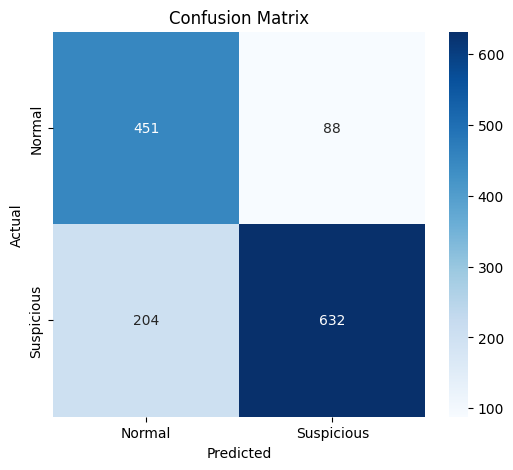

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Suspicious"],
            yticklabels=["Normal", "Suspicious"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()